Weights and Biases

In [10]:
inputs = [1,2,3,2.5]
weights1 = [0.2, 0.8, -0.5, 1.0]
weights2 = [0.5,-0.91, 0.26, -0.5]
weights3 = [-0.26,-0.27, 0.17, 0.87]
bias1 = 2
bias2 = 3
bias3 = 0.5

output = [inputs[0] * weights1[0] + inputs[1] * weights1[1] + inputs[2] * weights1[2] + inputs[3] * weights1[3] + bias1, \
inputs[0] * weights2[0] + inputs[1] * weights2[1] + inputs[2] * weights2[2] + inputs[3] * weights2[3] + bias2, \
inputs[0] * weights3[0] + inputs[1] * weights3[1] + inputs[2] * weights3[2] + inputs[3] * weights3[3] + bias3]

print(output)

[4.8, 1.21, 2.385]


Dot Product in NN

In [11]:
weights = [[0.2, 0.8, -0.5, 1.0], [0.5,-0.91, 0.26, -0.5], [-0.26,-0.27, 0.17, 0.87]]
biases = [2, 3, 0.5]

layers_outputs = [] #outputs of the current layer
for neuron_weights, neuron_bias in zip(weights, biases):
    neuron_output = 0 #output of the current neuron
    for n_input, weight in zip(inputs, neuron_weights):
        neuron_output += n_input * weight
    neuron_output += neuron_bias
    layers_outputs.append(neuron_output)
print(layers_outputs)

[4.8, 1.21, 2.385]


The dot Product

In [15]:
import numpy as np
inputs = [1,2,3,2.5]
weights = [[0.2, 0.8, -0.5, 1.0], 
           [0.5,-0.91, 0.26, -0.5], 
           [-0.26,-0.27, 0.17, 0.87]]

bias = [2, 3, 0.5]

output = np.dot(np.array(weights), np.array(inputs)) + np.array(bias)
print(output)

[4.79999995 1.21000004 2.38499999]


Batches, Layers and Objects

In [16]:
#batch size of 32 is common
inputs = [[1,2,3,2.5], 
          [2.0, 5.0, -1.0, 2.0], 
          [-1.5, 2.7, 3.3, -0.8]]
weights = [[0.2, 0.8, -0.5, 1.0], 
           [0.5,-0.91, 0.26, -0.5], 
           [-0.26,-0.27, 0.17, 0.87]]
bias = [2, 3, 0.5]

output = np.dot(np.array(weights), np.array(inputs).T).T + np.array(bias)
print(output)

[[ 4.79999995  1.21000004  2.38499999]
 [ 8.9000001  -1.80999994  0.19999999]
 [ 1.41000003  1.051       0.02599999]]


Adding a second layer

In [18]:

weights2 = [[0.1, -0.14, 0.5],
            [-0.5, 0.12, -0.33],    
            [-0.44, 0.73, -0.13]]
biases2 = [-1, 2, -0.5]

layer1_outputs = np.dot(np.array(inputs), np.array(weights).T) + np.array(bias)

layer2_outputs = np.dot(layer1_outputs, np.array(weights2).T) + np.array(biases2)

print(layer2_outputs)

[[ 0.50310004 -1.04184985 -2.03874993]
 [ 0.24339998 -2.73320007 -5.76329994]
 [-0.99314     1.41254002 -0.35655001]]


In [20]:
import numpy as np

np.random.seed(0)

X = np.array([[1,2,3,2.5], 
              [2.0, 5.0, -1.0, 2.0], 
              [-1.5, 2.7, 3.3, -0.8]])

class Layer_Dense:
    def __init__(self,n_inputs, n_neurons):
        self.weights = 0.1*np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.output = np.dot(np.array(inputs), self.weights) + self.biases

layer1 = Layer_Dense(4,5)
layer2 = Layer_Dense(5,2)

layer1.forward(X)
print(layer1.output)
layer2.forward(layer1.output)
print(layer2.output)


[[ 0.10758132  1.0398352   0.2446241   0.31821495  0.18851054]
 [-0.08349796  0.70846415  0.00293357  0.44701523  0.3636054 ]
 [-0.50763243  0.5568842   0.07987796 -0.34889573  0.04553042]]
[[ 0.148296   -0.08397602]
 [ 0.14100316 -0.01340469]
 [ 0.20124978 -0.07290616]]


Hidden Layer Activation Function

In [ ]:
# weights and biases are linear. Activation function are required to fit in nonlinear data.
# ReLU is granular, fast and simple. (Almost linear)
import numpy as np
import nnfs

nnfs.init()

inputs = [0,2,-1,3.3,-2.7,1.1,2.2,-100]
output = []
for i in inputs:
    output.append(max(0,i))
print(output)

X = np.array([[1,2,3,2.5], 
              [2.0, 5.0, -1.0, 2.0], 
              [-1.5, 2.7, 3.3, -0.8]])

class Layer_Dense:
    def __init__(self,n_inputs, n_neurons):
        self.weights = 0.1*np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.output = np.dot(np.array(inputs), self.weights) + self.biases

class Activation_ReLU:
    def forward(self,inputs):
        self.output = np.maximum(0,inputs)

layer1 = Layer_Dense(4,5)
activation1 = Activation_ReLU()
layer2 = Layer_Dense(5,2)

layer1.forward(X)
activation1.forward(layer1.output)
print(activation1.output)
layer2.forward(activation1.output)
print(layer2.output)


[0, 2, 0, 3.3, 0, 1.1, 2.2, 0]
[[0.10758132 1.0398352  0.2446241  0.31821495 0.18851054]
 [0.         0.70846415 0.00293357 0.44701523 0.3636054 ]
 [0.         0.5568842  0.07987796 0.         0.04553042]]
[[ 0.148296   -0.08397602]
 [ 0.11968622 -0.00794711]
 [ 0.07324824 -0.04625713]]


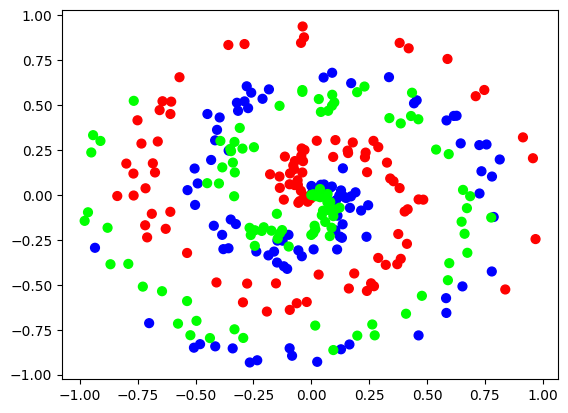

In [ ]:
np.random.seed(0)


def create_data(points, classes):
    X = np.zeros((points*classes, 2))
    y = np.zeros(points*classes, dtype='uint8')
    for class_number in range(classes):
        ix = range(points*class_number, points*(class_number+1))
        r = np.linspace(0.0,1,points)
        t = np.linspace(class_number*4,(class_number+1)*4,points) + np.random.randn(points)*0.2
        X[ix] = np.c_[r*np.sin(t*2.5), r*np.cos(t*2.5)]
        y[ix] = class_number
    return X,y

import matplotlib.pyplot as plt

X, y = create_data(100, 3)
plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap='brg')
plt.show()


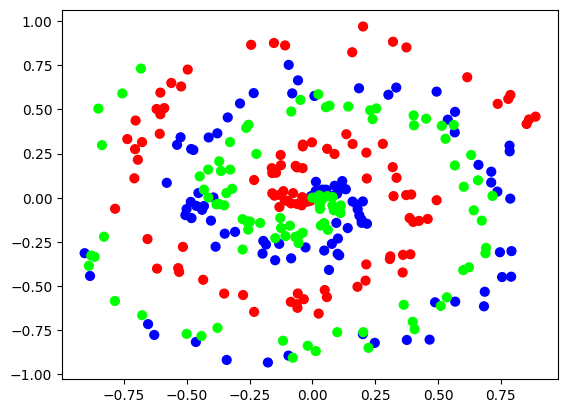

[[ 0.          0.          0.          0.          0.        ]
 [ 0.00126483  0.00069295 -0.00077178  0.00138571  0.00051675]
 [ 0.00091247 -0.00146651  0.00053962 -0.00137558 -0.00146815]
 ...
 [ 0.00770056  0.11340889 -0.06557854  0.14032778  0.10536874]
 [ 0.11840948  0.11660205 -0.10109406  0.19221024  0.09680557]
 [ 0.12650178  0.0916194  -0.08963067  0.16554399  0.07257262]]
[[0.         0.         0.         0.         0.        ]
 [0.00126483 0.00069295 0.         0.00138571 0.00051675]
 [0.00091247 0.         0.00053962 0.         0.        ]
 ...
 [0.00770056 0.11340889 0.         0.14032778 0.10536874]
 [0.11840948 0.11660205 0.         0.19221024 0.09680557]
 [0.12650178 0.0916194  0.         0.16554399 0.07257262]]


In [28]:
from nnfs.datasets import spiral_data

X,y = spiral_data(100,3)
plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap='brg')
plt.show()

layer1 = Layer_Dense(2,5)
activation1 = Activation_ReLU()

layer1.forward(X) 
print(layer1.output)
activation1.forward(layer1.output)
print(activation1.output)



Softmax Activation Function
Combination of exponentiation and normalization 
S(i,j) = e^zi,j/ Sum(e^zi,j)

In [ ]:
import math
import nnfs

layers_outputs = [4.8, 1.21, 2.385]

E = math.e

exp_values = np.exp(layers_outputs)

print(exp_values)

'''norm_base = sum(exp_values)
norm_values = []

for value in exp_values:
    norm_values.append(value / norm_base)'''

norm_values = exp_values / np.sum(exp_values)

print(norm_values)
print(sum(norm_values)) #should be 1.0

#Now we want to convert this to work as a batch of input values

layers_outputs = [[4.8, 1.21, 2.385],
                  [8.9, -1.81, 0.2],
                  [1.41, 1.051, 0.026]]

exp_values = np.exp(layers_outputs)
print(exp_values)
print(np.sum(layers_outputs, axis=1, keepdims=True))
norm_values = exp_values / np.sum(exp_values, axis=1, keepdims=True)
print(norm_values)
 #we subtract from max value to prevent overflow

[121.51041752   3.35348465  10.85906266]
[0.89528266 0.02470831 0.08000903]
0.9999999999999999
[[1.21510418e+02 3.35348465e+00 1.08590627e+01]
 [7.33197354e+03 1.63654137e-01 1.22140276e+00]
 [4.09595540e+00 2.86051020e+00 1.02634095e+00]]
[[8.395]
 [7.29 ]
 [2.487]]
[[8.95282664e-01 2.47083068e-02 8.00090293e-02]
 [9.99811129e-01 2.23163963e-05 1.66554348e-04]
 [5.13097164e-01 3.58333899e-01 1.28568936e-01]]


In [39]:
class Layer_Dense:
    def __init__(self,n_inputs, n_neurons):
        self.weights = 0.1*np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.output = np.dot(np.array(inputs), self.weights) + self.biases

class Activation_ReLU:
    def forward(self,inputs):
        self.output = np.maximum(0,inputs)

class Activation_Softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities

X,y = spiral_data(samples = 100, classes = 3)

dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)
print(activation2.output)

[[0.33333334 0.33333334 0.33333334]
 [0.33329678 0.33344617 0.33325705]
 [0.33325663 0.33356994 0.33317345]
 [0.33324578 0.3336034  0.33315083]
 [0.3332143  0.33370048 0.3330852 ]
 [0.33318415 0.3338746  0.33294123]
 [0.3331482  0.33390418 0.3329476 ]
 [0.33309898 0.33405593 0.3328451 ]
 [0.33301675 0.33430916 0.33267412]
 [0.33305755 0.33432382 0.33261862]
 [0.33307147 0.33432785 0.33260068]
 [0.33289835 0.3346734  0.33242822]
 [0.33289623 0.3347914  0.33231238]
 [0.33288452 0.33471602 0.33239946]
 [0.33280215 0.33506182 0.332136  ]
 [0.33274293 0.33518824 0.33206883]
 [0.33270508 0.33531433 0.3319806 ]
 [0.33335418 0.33371064 0.33293515]
 [0.33269355 0.3354935  0.33181292]
 [0.33275375 0.33541653 0.33182976]
 [0.3330803  0.33459702 0.3323227 ]
 [0.33350143 0.33334884 0.3331497 ]
 [0.33327717 0.33407435 0.3326485 ]
 [0.33332956 0.333459   0.33321142]
 [0.3332     0.33435643 0.33244354]
 [0.3334595  0.3335916  0.33294886]
 [0.33354244 0.33335158 0.33310604]
 [0.33339855 0.3334544  0.33

Calculating Loss with Categorical Cross Entropy
How wrong is the model?

In [40]:
#Mean absolute error - Regression
#Since we are doing  classification, where our model is outputting probabilities, we will use categorical cross-entropy loss.
# Li = -sum(yi,j * log(pi,j)) where yi is the true label and pi is the predicted probability for class i. We sum over all classes j.

#One hot encoding 

import math

softmax_output = [0.7,0.1,0.2]
target_output = [1,0,0]

loss = -(math.log(softmax_output[0])*target_output[0] + 
         math.log(softmax_output[1])*target_output[1] + 
         math.log(softmax_output[2])*target_output[2])

print(loss)

0.35667494393873245


Implementing Loss

In [ ]:
import numpy as np
softmax_outputs = np.array([[0,0.1,0.2],
                           [0.1,0.5,0.4],
                           [0.02,0.9,0.08]])    
class_targets = np.array([0,1,1])
print(-np.log(softmax_outputs[[0,1,2],[class_targets]]))
#infinity as one of the values is 0. We can add a small value to prevent this.
epsilon = 1e-15
print(-np.log(softmax_outputs[[0,1,2],[class_targets]] + epsilon))


[[       inf 0.69314718 0.10536052]]
[[34.53877639  0.69314718  0.10536052]]


C:\Users\hp\AppData\Local\Temp\ipykernel_6540\2486145184.py:6: RuntimeWarning: divide by zero encountered in log
  print(-np.log(softmax_outputs[[0,1,2],[class_targets]]))


In [44]:
class Loss:
    def calculate(self,output,y):
        sample_losses = self.forward(output,y)
        data_loss = np.mean(sample_losses)
        return data_loss
class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred,y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true]
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods
    
loss_function = Loss_CategoricalCrossentropy()
loss = loss_function.calculate(activation2.output, y)
print(loss)

1.0982208


Introducing Optimization and derivatives

In [ ]:
#we want to decrease the loss
import matplotlib.pyplot as plt

import nnfs
from nnfs.datasets import vertical_data
nnfs.init()

X, y = vertical_data(samples=100, classes=3)

dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()

loss_function = Loss_CategoricalCrossentropy()

lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
    dense1.weights += 0.05 * np.random.randn(2,3)
    dense1.biases += 0.05 * np.random.randn(1,3)
    dense2.weights += 0.05 * np.random.randn(3,3)
    dense2.biases += 0.05 * np.random.randn(1,3)

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    loss = loss_function.calculate(activation2.output, y)

    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions==y)

    if loss < lowest_loss:
        print('New set of weights found, iteration:', iteration, 'loss:', loss, 'accuracy:', accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss
    else:
        dense1.weights = best_dense1_weights.copy()
        dense1.biases = best_dense1_biases.copy()
        dense2.weights = best_dense2_weights.copy()
        dense2.biases = best_dense2_biases.copy()

#randomly searching for weights and biases is not efficient. We will use gradient descent to find the optimal weights and biases.
#random search is a huge problem with nonlinear dataset. So we need to use other optimization algorithms like gradient descent, Adam, RMSprop etc. to find the optimal weights and biases.


New set of weights found, iteration: 0 loss: 1.0984223 accuracy: 0.3333333333333333
New set of weights found, iteration: 4 loss: 1.0983797 accuracy: 0.3333333333333333
New set of weights found, iteration: 5 loss: 1.0973538 accuracy: 0.33666666666666667
New set of weights found, iteration: 6 loss: 1.0963587 accuracy: 0.26666666666666666
New set of weights found, iteration: 8 loss: 1.0953789 accuracy: 0.34
New set of weights found, iteration: 14 loss: 1.095357 accuracy: 0.3333333333333333
New set of weights found, iteration: 21 loss: 1.0940696 accuracy: 0.3333333333333333
New set of weights found, iteration: 24 loss: 1.0937893 accuracy: 0.3333333333333333
New set of weights found, iteration: 25 loss: 1.0903312 accuracy: 0.62
New set of weights found, iteration: 27 loss: 1.0894265 accuracy: 0.3333333333333333
New set of weights found, iteration: 28 loss: 1.0862789 accuracy: 0.3333333333333333
New set of weights found, iteration: 29 loss: 1.0799779 accuracy: 0.5933333333333334
New set of w

In [ ]:
#we want to decrease the loss
import matplotlib.pyplot as plt

import nnfs
from nnfs.datasets import spiral_data
nnfs.init()

X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()

loss_function = Loss_CategoricalCrossentropy()

lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
    dense1.weights += 0.05 * np.random.randn(2,3)
    dense1.biases += 0.05 * np.random.randn(1,3)
    dense2.weights += 0.05 * np.random.randn(3,3)
    dense2.biases += 0.05 * np.random.randn(1,3)

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    loss = loss_function.calculate(activation2.output, y)

    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions==y)

    if loss < lowest_loss:
        print('New set of weights found, iteration:', iteration, 'loss:', loss, 'accuracy:', accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss
    else:
        dense1.weights = best_dense1_weights.copy()
        dense1.biases = best_dense1_biases.copy()
        dense2.weights = best_dense2_weights.copy()
        dense2.biases = best_dense2_biases.copy()
        
#randomly searching for weights and biases is not efficient. We will use gradient descent to find the optimal weights and biases.
